https://github.com/zygmuntz/goodbooks-10k

In [ ]:
pip install kaggle

In [5]:
!pip uninstall -y numpy pandas


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
You can safely remove it manually.
You can safely remove it manually.
Found existing installation: pandas 1.4.4
Uninstalling pandas-1.4.4:
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.9/shutil.py", line 825, in move
    os.rename(src, real_dst)
PermissionError: [Errno 13] Permission denied: '/usr/local/anaconda3/lib/python3.9/site-packages/pandas-1.4.4-py3.9.egg-info' -> '/tmp/pip-uninstall-w63m7qxe'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/moshtasa/.local/lib/python3.9/site-packages/pip/_internal/cli/base_command.py", line 105, in _run_wrapper
    status = _inner_run()
  File "/home/moshtasa/.local/lib/python3.9/site-packages/pip/_internal/cli/base_command.py", line 96, in _inner_run
    return self.run(options, args)
  File "/home/moshtasa/.local/lib/pyth

In [6]:
!pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [7]:
!pip install numpy pandas

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
pip install kagglehub

In [1]:
import os
import pandas as pd

In [3]:
# Define your local data path
data_path = '../data/goodbooks-10k'  # adjust path if needed

# Load all available CSV files
books = pd.read_csv(os.path.join(data_path, 'books.csv'))
ratings = pd.read_csv(os.path.join(data_path, 'ratings.csv'))
to_read = pd.read_csv(os.path.join(data_path, 'to_read.csv'))
book_tags = pd.read_csv(os.path.join(data_path, 'book_tags.csv'))
tags = pd.read_csv(os.path.join(data_path, 'tags.csv'))

# Quick verification:
print(f"books.csv shape: {books.shape}")
print(f"ratings.csv shape: {ratings.shape}")
print(f"to_read.csv shape: {to_read.shape}")
print(f"book_tags.csv shape: {book_tags.shape}")
print(f"tags.csv shape: {tags.shape}")

# Preview few rows from each file:
print("\nBooks sample:")
print(books.head())

print("\nRatings sample:")
print(ratings.head())

print("\nTo-Read sample:")
print(to_read.head())

print("\nBook Tags sample:")
print(book_tags.head())

print("\nTags sample:")
print(tags.head())


books.csv shape: (10000, 23)
ratings.csv shape: (5976479, 3)
to_read.csv shape: (912705, 2)
book_tags.csv shape: (999912, 3)
tags.csv shape: (34252, 2)

Books sample:
   book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   
3        4               2657          2657  3275794          487   61120081   
4        5               4671          4671   245494         1356  743273567   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   
3  9.780061e+12                   Harper Lee        

In [ ]:
# import pandas as pd
# import os

# # Load books.csv
# data_path = '../data/goodbooks-10k'
# books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# # Total number of books
# total_books = len(books)

# # Total number of unique languages (excluding NaN)
# unique_languages = books['language_code'].nunique()

# # Number of books with missing language_code
# missing_languages = books['language_code'].isnull().sum()

# # Count number of books per language
# books_per_language = books['language_code'].value_counts()

# # Full list of languages
# languages_list = books['language_code'].dropna().unique()

# # Print summary
# print(f"Total number of books: {total_books}")
# print(f"Total unique languages: {unique_languages}")
# print(f"Number of books missing language info: {missing_languages}\n")

# print("Number of books per language:")
# print(books_per_language)

# print("\nList of languages:")
# print(languages_list)


In [19]:
import pandas as pd

# Load cleaned data
data_path = '../data/goodbooks-10k'
books = pd.read_csv(f"{data_path}/books.csv")
ratings = pd.read_csv(f"{data_path}/ratings.csv")

# Step 1: Create decade column
books['decade'] = (books['original_publication_year'] // 10) * 10

# Step 2: Group by conditions
def assign_decade_label(x):
    if pd.isna(x):
        return 'Not Available'
    elif x < 1920:
        return 'Ancient Books'
    else:
        return int(x)

books['decade_grouped'] = books['decade'].apply(assign_decade_label)

# Step 3: Merge ratings with books (attach decade info)
merged_df = ratings.merge(books[['book_id', 'decade_grouped']], on='book_id', how='left')

# Step 4: Rename columns for clarity
final_df = merged_df.rename(columns={'decade_grouped': 'decade'})

# Step 5: Reorder columns
final_df = final_df[['user_id', 'book_id', 'rating', 'decade']]

# Step 6: Save final dataset
final_df.to_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final.csv", index=False)

# Print sample and shape for verification
print(final_df.head())
print(f"\nFinal dataset shape: {final_df.shape}")


   user_id  book_id  rating decade
0        1      258       5   2000
1        2     4081       4   2000
2        2      260       5   1930
3        2     9296       5   1970
4        2     2318       3   1990

Final dataset shape: (5976479, 4)


In [20]:
import pandas as pd

# Load your final dataset
data_path = '../data'
df = pd.read_csv(f"{data_path}/df_final.csv")

# Count unique book_id per decade
books_per_decade = (
    df.groupby('decade')['book_id']
    .nunique()
    .reset_index(name='unique_books')
    .sort_values(by='decade')
)

print("\nUnique books per decade:")
print(books_per_decade)



Unique books per decade:
           decade  unique_books
0            1920            89
1            1930           121
2            1940           155
3            1950           210
4            1960           272
5            1970           400
6            1980           704
7            1990          1360
8            2000          3121
9            2010          3067
10  Ancient Books           480
11  Not Available            21


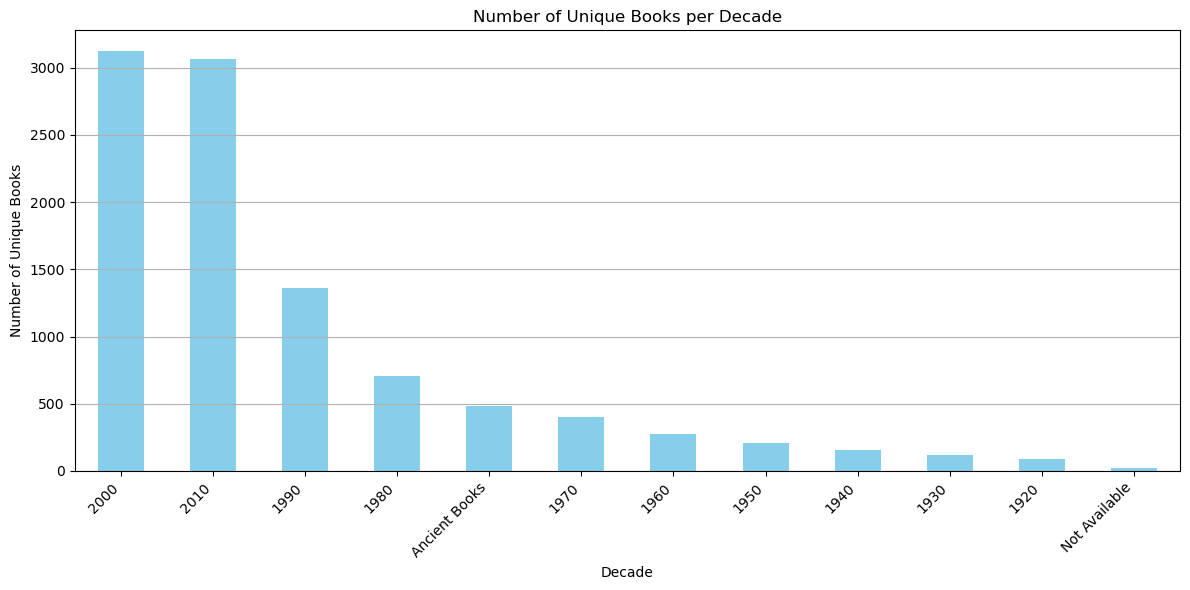


🔍 Missing Value Report:
Missing ratings: 0
Missing user IDs: 0
Missing book IDs: 0
Missing decades: 0

🧾 Number of duplicate rows: 0

📊 Total rows: 5976479
✅ Non-null ratings: 5976479
✔️ All rows have a rating.

📌 Dataset Summary:
Unique users: 53424
Unique books: 10000
Unique decades: 12
Average ratings per user: 111.87
Min ratings per user: 19
Max ratings per user: 200


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your df_final dataset
df_path = "../data/df_final.csv"  # update path if needed
df = pd.read_csv(df_path)

# ========== User & Book Statistics ==========
unique_users = df['user_id'].nunique()
unique_books = df['book_id'].nunique()
ratings_per_user = df.groupby('user_id').size()
average_ratings_per_user = ratings_per_user.mean()
min_ratings_per_user = ratings_per_user.min()
max_ratings_per_user = ratings_per_user.max()

# ========== Decade Statistics ==========
unique_decades = df['decade'].nunique()
books_per_decade = df.groupby('decade')['book_id'].nunique().sort_values(ascending=False)

# ========== Plot: Books per Decade ==========
plt.figure(figsize=(12, 6))
books_per_decade.plot(kind='bar', color='skyblue')
plt.title('Number of Unique Books per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# ========== Missing Values ==========
missing_values = {
    "Missing ratings": df['rating'].isnull().sum(),
    "Missing user IDs": df['user_id'].isnull().sum(),
    "Missing book IDs": df['book_id'].isnull().sum(),
    "Missing decades": df['decade'].isnull().sum()
}

print("\n🔍 Missing Value Report:")
for key, val in missing_values.items():
    print(f"{key}: {val}")

# ========== Duplicate Rows ==========
duplicate_rows = df.duplicated().sum()
print(f"\n🧾 Number of duplicate rows: {duplicate_rows}")

# ========== Ratings Info ==========
total_rows = len(df)
non_null_ratings = df['rating'].notnull().sum()
print(f"\n📊 Total rows: {total_rows}")
print(f"✅ Non-null ratings: {non_null_ratings}")

if total_rows == non_null_ratings:
    print("✔️ All rows have a rating.")
else:
    print("⚠️ Some rows are missing a rating.")

# ========== Summary ==========
print("\n📌 Dataset Summary:")
print(f"Unique users: {unique_users}")
print(f"Unique books: {unique_books}")
print(f"Unique decades: {unique_decades}")
print(f"Average ratings per user: {average_ratings_per_user:.2f}")
print(f"Min ratings per user: {min_ratings_per_user}")
print(f"Max ratings per user: {max_ratings_per_user}")


In [55]:
import pandas as pd

# Load the books.csv file
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# Define common variations of J.K. Rowling's name
name_variations = [ 'sartre', 'sarter']

# Combine into a regex pattern for case-insensitive search
pattern = '|'.join(name_variations)

# Search for rows where the 'author' column contains any of the variations
rowling_books = books[books['authors'].str.lower().str.contains(pattern, na=False)]

# Display result
print(rowling_books['title'].unique())

['Nausea' 'Being and Nothingness' 'No Exit and Three Other Plays'
 'No Exit' 'The Wall' 'Existentialism Is a Humanism'
 'The Wretched of the Earth']


In [22]:
import pandas as pd
import os

# Load the books.csv file
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# Count unique authors
unique_authors = books['authors'].nunique()

# Print the count
print(f"Number of unique authors: {unique_authors}")


Number of unique authors: 4664


In [46]:
# Define Persian language variations
persian_lang_variants = ['per', 'persian', 'fa']

# Filter rows where language column matches any variant (case-insensitive)
persian_books = books[books['language_code'].str.lower().isin(persian_lang_variants)]
# Show only the book titles
print(persian_books['title'])

6148       عقاید یک دلقک
6759        رباعيات خيام
7469              سینوهه
7623       درخت زیبای من
8319    ماهی سیاه کوچولو
8864       سمفونی مردگان
9837            هشت کتاب
Name: title, dtype: object


In [59]:
# Group by title and collect all unique years per title
title_years = books.groupby('title')['original_publication_year'].unique()

# Filter only titles that have more than 1 unique year
multiple_year_titles = title_years[title_years.apply(lambda x: len(x) > 1)]

# Print count
print(f"Number of titles with multiple publication years: {len(multiple_year_titles)}")

# Print sample (first 10 titles)
for title, years in multiple_year_titles.head(10).items():
    print(f"\nTitle: {title}")
    print(f"Years: {sorted(years)}")

# Total unique book IDs in ratings file
total_unique_books_in_ratings = ratings['book_id'].nunique()

# Total unique book IDs in books file (metadata)
total_unique_books_in_books = books['book_id'].nunique()



Number of titles with multiple publication years: 33

Title: 'Salem's Lot
Years: [1975, 2005]

Title: Anatomy for the Artist
Years: [1953, 2001]

Title: Arcadia
Years: [1993, 2012]

Title: Are You My Mother?
Years: [1960, 2012]

Title: Bambi
Years: [1923, 1941]

Title: Between the Lines (Between the Lines, #1)
Years: [2011, 2012]

Title: Invisible
Years: [2009, 2014]

Title: Leviathan
Years: [1651, 1992]

Title: Monster
Years: [1999, 2005]

Title: One Flew Over the Cuckoo's Nest
Years: [1962, 1970]


In [25]:
import pandas as pd
import os

# Load data
data_path = '../data/goodbooks-10k'
books = pd.read_csv(f"{data_path}/books.csv")
ratings = pd.read_csv(f"{data_path}/ratings.csv")

# Create decade column and merge
books['decade'] = (books['original_publication_year'] // 10) * 10
merged_df = ratings.merge(books[['book_id', 'decade']], on='book_id')

# Groupby decade: count unique books & total ratings
summary = merged_df.groupby('decade').agg(
    unique_books=('book_id', 'nunique'),
    total_ratings=('rating', 'count')
).reset_index().sort_values('decade')

total_ratings_sum = summary['total_ratings'].sum()
print(f"Sum of total ratings from summary: {total_ratings_sum}")

total_ratings_actual = len(ratings)
print(f"Total number of ratings from ratings.csv: {total_ratings_actual}")


# Print results
print("Unique books per decade and total ratings:")
print(summary)


Sum of total ratings from summary: 5970537
Total number of ratings from ratings.csv: 5976479
Unique books per decade and total ratings:
    decade  unique_books  total_ratings
0  -1750.0             1            730
1   -770.0             1            756
2   -750.0             2           3944
3   -720.0             1           6301
4   -560.0             1           1548
..     ...           ...            ...
78  1970.0           400         244194
79  1980.0           704         443368
80  1990.0          1360         847948
81  2000.0          3121        1808808
82  2010.0          3067        1268418

[83 rows x 3 columns]


In [26]:
# How many unique book_ids exist in ratings but not in books
missing_books = set(ratings['book_id']) - set(books['book_id'])
print(f"Number of book_ids in ratings.csv not found in books.csv: {len(missing_books)}")

Number of book_ids in ratings.csv not found in books.csv: 0


In [62]:
total_books = books['book_id'].nunique()
print(f"Total unique books: {total_books}")

Total unique books: 9979


In [27]:
total_ratings = len(ratings)
print(f"Total ratings: {total_ratings}")

Total ratings: 5976479


In [63]:
# Add decade
books['decade'] = (books['original_publication_year'] // 10) * 10

# Count books per decade (this is from full books.csv not merged one!)
books_per_decade = books.groupby('decade')['book_id'].nunique().reset_index(name='unique_books')

# Summation of books across decades
total_books_from_decades = books_per_decade['unique_books'].sum()

print("Books per decade:")
print(books_per_decade)
print(f"\nSummation of books across decades: {total_books_from_decades}")


Books per decade:
    decade  unique_books
0    -1750             1
1     -770             1
2     -750             2
3     -720             1
4     -560             1
..     ...           ...
78    1970           400
79    1980           704
80    1990          1360
81    2000          3121
82    2010          3067

[83 rows x 2 columns]

Summation of books across decades: 9979


In [29]:
# Load cleaned data
data_path = '../data/goodbooks-10k'
books = pd.read_csv(f"{data_path}/books.csv")
ratings = pd.read_csv(f"{data_path}/ratings.csv")

# 1️⃣ Count unique book_id in books.csv
unique_books_in_books = books['book_id'].nunique()
print(f"Total unique book_ids in books.csv: {unique_books_in_books}")

# 2️⃣ Count unique book_id in ratings.csv
unique_books_in_ratings = ratings['book_id'].nunique()
print(f"Total unique book_ids in ratings.csv: {unique_books_in_ratings}")

# 3️⃣ Count total ratings
total_ratings = len(ratings)
print(f"Total ratings: {total_ratings}")

# 4️⃣ Compute decade column
books['decade'] = (books['original_publication_year'] // 10) * 10

# 5️⃣ Count number of unique books per decade
books_per_decade = books.groupby('decade')['book_id'].nunique().reset_index(name='unique_books_per_decade')
books_per_decade = books_per_decade.sort_values('decade')

print("\nBooks per decade:")
print(books_per_decade)

# 6️⃣ Verify summation of books across decades
total_books_from_decades = books_per_decade['unique_books_per_decade'].sum()
print(f"\nSummation of books across decades: {total_books_from_decades}")


Total unique book_ids in books.csv: 10000
Total unique book_ids in ratings.csv: 10000
Total ratings: 5976479

Books per decade:
    decade  unique_books_per_decade
0  -1750.0                        1
1   -770.0                        1
2   -750.0                        2
3   -720.0                        1
4   -560.0                        1
..     ...                      ...
78  1970.0                      400
79  1980.0                      704
80  1990.0                     1360
81  2000.0                     3121
82  2010.0                     3067

[83 rows x 2 columns]

Summation of books across decades: 9979


In [30]:
books_per_decade

,decade,unique_books_per_decade
0,-1750.0,1
1,-770.0,1
2,-750.0,2
3,-720.0,1
4,-560.0,1
...,...,...
78,1970.0,400
79,1980.0,704
80,1990.0,1360
81,2000.0,3121


## computing user_entropy and clustering - initiate

In [31]:
# Step 1: Count number of ratings per user per decade
user_decade_counts = final_df.groupby(['user_id', 'decade']).size().unstack(fill_value=0)

# Step 2: Normalize counts so each user's row sums to 1
user_decade_normalized = user_decade_counts.div(user_decade_counts.sum(axis=1), axis=0)

# Step 3: Rename columns to indicate normalization
user_decade_normalized.columns = [f'{c}_norm' for c in user_decade_normalized.columns]

# Step 4: Merge raw counts with normalized values
user_decade_merged = pd.concat([user_decade_counts, user_decade_normalized], axis=1).reset_index()

# Step 5: Preview the result
print(user_decade_merged.head())


   user_id  1920  1930  1940  1950  1960  1970  1980  1990  2000  ...  \
0        1     0     3     4     3     4     2    15     9    48  ...   
1        2     2     3     2     4     2     4     2    12    21  ...   
2        3     3     5     6     5     4     3     9    21    19  ...   
3        4     4     7     7    10    14     9    20    24    24  ...   
4        5     0     1     0     1     1     1    10    11    17  ...   

   1940_norm  1950_norm  1960_norm  1970_norm  1980_norm  1990_norm  \
0   0.034188   0.025641   0.034188   0.017094   0.128205   0.076923   
1   0.030769   0.061538   0.030769   0.061538   0.030769   0.184615   
2   0.065934   0.054945   0.043956   0.032967   0.098901   0.230769   
3   0.052239   0.074627   0.104478   0.067164   0.149254   0.179104   
4   0.000000   0.010000   0.010000   0.010000   0.100000   0.110000   

   2000_norm  2010_norm  Ancient Books_norm  Not Available_norm  
0   0.410256   0.119658            0.128205                 0.0  
1 


✅ User entropy file saved: ../preprocessing/user_entropy_quantile_books.csv


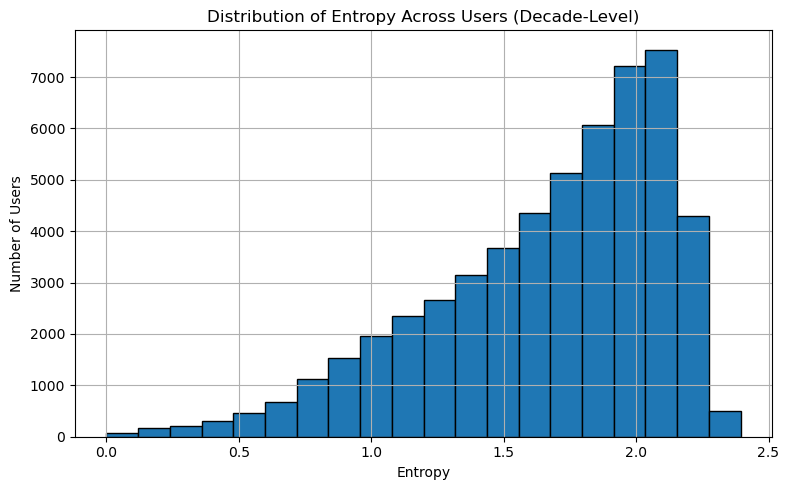


Entropy histogram distribution:
Entropy range [0.000, 0.120): 63 users
Entropy range [0.120, 0.239): 170 users
Entropy range [0.239, 0.359): 203 users
Entropy range [0.359, 0.479): 305 users
Entropy range [0.479, 0.599): 463 users
Entropy range [0.599, 0.718): 678 users
Entropy range [0.718, 0.838): 1117 users
Entropy range [0.838, 0.958): 1538 users
Entropy range [0.958, 1.077): 1962 users
Entropy range [1.077, 1.197): 2348 users
Entropy range [1.197, 1.317): 2663 users
Entropy range [1.317, 1.437): 3149 users
Entropy range [1.437, 1.556): 3680 users
Entropy range [1.556, 1.676): 4357 users
Entropy range [1.676, 1.796): 5137 users
Entropy range [1.796, 1.916): 6061 users
Entropy range [1.916, 2.035): 7208 users
Entropy range [2.035, 2.155): 7533 users
Entropy range [2.155, 2.275): 4290 users
Entropy range [2.275, 2.394): 499 users


In [32]:
import pandas as pd
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Step 1: Count how many books each user rated in each decade
user_decade_counts = final_df.groupby(['user_id', 'decade']).size().unstack(fill_value=0)

# Step 2: Normalize counts to get per-user decade distributions
user_decade_normalized = user_decade_counts.div(user_decade_counts.sum(axis=1), axis=0)
user_decade_normalized.columns = [f"{c}_norm" for c in user_decade_normalized.columns]

# Step 3: Calculate entropy (diversity of preferences) per user
user_entropy = user_decade_normalized.apply(lambda x: entropy(x), axis=1).to_frame(name='entropy')
user_entropy.reset_index(inplace=True)

# Step 4: Quantile-Based Clustering (3 clusters: low, mid, high diversity)
user_entropy_sorted = user_entropy.sort_values(by='entropy').reset_index(drop=True)
n_users = len(user_entropy_sorted)
user_entropy_sorted['cluster'] = pd.cut(
    user_entropy_sorted.index,
    bins=[-1, n_users // 3, 2 * n_users // 3, n_users],
    labels=[0, 1, 2]
).astype(int)

# Optional: Save the result
output_path = "../preprocessing/user_entropy_quantile_books.csv"
user_entropy_sorted.to_csv(output_path, index=False)
print(f"\n✅ User entropy file saved: {output_path}")

# Step 5: Plot histogram of entropy values & get counts
plt.figure(figsize=(8, 5))
counts, bin_edges, _ = plt.hist(user_entropy_sorted['entropy'], bins=20, edgecolor='black')
plt.title('Distribution of Entropy Across Users (Decade-Level)')
plt.xlabel('Entropy')
plt.ylabel('Number of Users')
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Print the histogram distribution as text
print("\nEntropy histogram distribution:")
for i in range(len(counts)):
    print(f"Entropy range [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}): {int(counts[i])} users")


#### leave the clustering steps 


In [10]:
import pandas as pd
import os

data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# Select columns by passing a list of their names as strings
subset = books[['book_id', 'title', 'authors', 'original_title']]

subset.head()


,book_id,title,authors,original_title
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,The Hunger Games
1,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",Harry Potter and the Philosopher's Stone
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,Twilight
3,4,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird
4,5,The Great Gatsby,F. Scott Fitzgerald,The Great Gatsby


In [11]:
books["original_title"].nunique()

9274

## LLM

In [9]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [16]:
import os
import pandas as pd
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import multiprocessing as mp
import re

# === Define the sample books dataset
sample_books = [
    {"book_id": 1, "original_title": "The Hobbit", "authors": "J.R.R. Tolkien"},
    {"book_id": 2, "original_title": "Pride and Prejudice", "authors": "Jane Austen"},
    {"book_id": 3, "original_title": "The Shining", "authors": "Stephen King"},
    {"book_id": 4, "original_title": "Dune", "authors": "Frank Herbert"},
    {"book_id": 5, "original_title": "The Diary of a Young Girl", "authors": "Anne Frank"},
    {"book_id": 6, "original_title": "Charlotte's Web", "authors": "E.B. White"},
    {"book_id": 7, "original_title": "The Da Vinci Code", "authors": "Dan Brown"},
    {"book_id": 8, "original_title": "Dracula", "authors": "Bram Stoker"},
    {"book_id": 9, "original_title": "War and Peace", "authors": "Leo Tolstoy"},
    {"book_id": 10, "original_title": "Fifty Shades of Grey", "authors": "E.L. James"},
    {"book_id": 11, "original_title": "Harry Potter and the Sorcerer's Stone", "authors": "J.K. Rowling"},
    {"book_id": 12, "original_title": "To Kill a Mockingbird", "authors": "Harper Lee"},
    {"book_id": 13, "original_title": "The Great Gatsby", "authors": "F. Scott Fitzgerald"},
    {"book_id": 14, "original_title": "The Hunger Games", "authors": "Suzanne Collins"},
    {"book_id": 15, "original_title": "Moby-Dick", "authors": "Herman Melville"},
]

df_books_sample = pd.DataFrame(sample_books)

GENRE_LIST = [
    "Fantasy", "Science Fiction", "Romance", "Mystery", "Thriller",
    "Historical", "Adult", "Horror", "Children's",
    "Adventure", "Classics", "Nonfiction", "Drama"
]
genre_options_str = ", ".join(GENRE_LIST)

# === Global pipe for multiprocessing
global_pipe = None

def init_model(model_name):
    """Initialize model pipeline in each worker process."""
    global global_pipe
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if "flan" in model_name.lower() or "t5" in model_name.lower():
        from transformers import AutoModelForSeq2SeqLM
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        global_pipe = pipeline("text2text-generation", model=model, tokenizer=tokenizer)
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name)
        global_pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def process_book(row):
    """Process a single book, returns exactly two predicted genres."""
    global global_pipe
    title = row['original_title']
    author = row['authors']

    prompt = f"""
You are a book genre classifier. Your job is to pick exactly two genres from the list below that best match the book title (and author, if given).

Examples:
- "The Hobbit" → Fantasy, Adventure
- "Pride and Prejudice" → Romance, Classics
- "The Shining" → Horror, Thriller

Now choose the two most appropriate genres for:
Title: "{title}"{f" by {author}" if author else ""}

Genres: {genre_options_str}
Respond ONLY with two genres separated by a comma.
"""
    result = global_pipe(prompt.strip(), max_new_tokens=50, temperature=0.2)
    raw_output = result[0]['generated_text'].strip()

    # Extract first two valid genres from the output using regex
    pattern = r"\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b\s*,\s*\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b"
    match = re.search(pattern, raw_output, re.IGNORECASE)
    if match:
        return f"{match.group(1)}, {match.group(2)}"

    return raw_output  # fallback: return raw output for inspection

def process_and_save_parallel(model_name, output_filename, num_workers=2):
    print(f"\n🚀 Loading model: {model_name} on {num_workers} parallel workers...")


    with mp.Pool(
        processes=num_workers,
        initializer=init_model,
        initargs=(model_name,)
    ) as pool:
        genres = list(tqdm(
            pool.imap(process_book, df_books_sample.to_dict(orient="records")),
            total=len(df_books_sample)
        ))

    df_books_sample['genres'] = genres
    df_books_sample.to_csv(output_filename, index=False)
    print(f"✅ Saved genres dataset: {output_filename}")

if __name__ == "__main__":
    tasks = [
        ("meta-llama/Llama-3-8b-instruct", "../data/LLM/books_genres_llama3.csv"),
    ]
    num_workers = 2

    for model_name, output_filename in tasks:
        process_and_save_parallel(model_name, output_filename, num_workers)

    print("🎉 All models finished processing!")


# if __name__ == "__main__":
#     tasks = [
#         # Uncomment or add models as needed:
#        # ("HuggingFaceH4/zephyr-7b-beta", "../data/test/books_genres_zephyr.csv"),
#       #  ("mistralai/Mistral-7B-Instruct-v0.2", "../data/test/books_genres_mistral.csv"),
#        # ("meta-llama/Llama-3-8b-instruct", "../data/test/books_genres_llama3.csv"),
#       #  ("microsoft/phi-2", "../data/test/books_genres_phi2.csv"),
#         ("google/flan-t5-xl", "../data/test_llm/books_genres_flan_t5.csv"),
#     ]
#     num_workers = 2  # reduce workers to avoid overloading your server

#     processes = []
#     for model_name, output_filename in tasks:
#         p = mp.Process(
#             target=process_and_save_parallel,
#             args=(model_name, output_filename, num_workers)
#         )
#         p.start()
#         processes.append(p)

#     for p in processes:
#         p.join()

#     print("🎉 All models finished processing!")



🚀 Loading model: meta-llama/Llama-3-8b-instruct on 2 parallel workers...


  0%|          | 0/15 [00:00<?, ?it/s]

Process ForkPoolWorker-28:
Traceback (most recent call last):
Process ForkPoolWorker-29:
  File "/home/moshtasa/.local/lib/python3.9/site-packages/huggingface_hub/utils/_http.py", line 409, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/anaconda3/lib/python3.9/site-packages/requests/models.py", line 1021, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 404 Client Error: Not Found for url: https://huggingface.co/meta-llama/Llama-3-8b-instruct/resolve/main/tokenizer_config.json

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/moshtasa/.local/lib/python3.9/site-packages/huggingface_hub/utils/_http.py", line 409, in hf_raise_for_status
    response.raise_for_status()
  File "/home/moshtasa/.local/lib/python3.9/site-packages/transformers/utils/hub.py", line 470, in cached_files
    hf_hub_download(
  File "

KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import multiprocessing as mp
import re

# === Load dataset once globally ===
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))
df_books = books[['book_id', 'original_title', 'authors']].dropna(subset=['original_title'])
# === Sample 15 books for testing ===
sample_books = df_books.sample(n=, random_state=42).reset_index(drop=True)

df_books_sample = pd.DataFrame(sample_books)

GENRE_LIST = [
    "Fantasy", "Science Fiction", "Romance", "Mystery", "Thriller",
    "Historical", "Adult", "Horror", "Children's",
    "Adventure", "Classics", "Nonfiction", "Drama"
]
genre_options_str = ", ".join(GENRE_LIST)

# === Global pipe for multiprocessing
global_pipe = None

def init_model(model_name):
    """Initialize model pipeline in each worker process."""
    global global_pipe
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if "flan" in model_name.lower() or "t5" in model_name.lower():
        from transformers import AutoModelForSeq2SeqLM
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        global_pipe = pipeline("text2text-generation", model=model, tokenizer=tokenizer)
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name)
        global_pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def process_book(row):
    """Process a single book, returns exactly two predicted genres."""
    global global_pipe
    title = row['original_title']
    author = row['authors']

    prompt = f"""
You are a book genre classifier. Your job is to pick exactly two genres from the list below that best match the book title (and author, if given).

Examples:
- "The Hobbit" → Fantasy, Adventure
- "Pride and Prejudice" → Romance, Classics
- "The Shining" → Horror, Thriller

Now choose the two most appropriate genres for:
Title: "{title}"{f" by {author}" if author else ""}

Genres: {genre_options_str}
Respond ONLY with two genres separated by a comma.
"""
    result = global_pipe(prompt.strip(), max_new_tokens=50, temperature=0.2)
    raw_output = result[0]['generated_text'].strip()

    # Extract first two valid genres from the output using regex
    pattern = r"\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b\s*,\s*\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b"
    match = re.search(pattern, raw_output, re.IGNORECASE)
    if match:
        return f"{match.group(1)}, {match.group(2)}"

    return raw_output  # fallback: return raw output for inspection

def process_and_save_parallel(model_name, output_filename, num_workers=2):
    print(f"\n🚀 Loading model: {model_name} on {num_workers} parallel workers...")


    with mp.Pool(
        processes=num_workers,
        initializer=init_model,
        initargs=(model_name,)
    ) as pool:
        genres = list(tqdm(
            pool.imap(process_book, df_books_sample.to_dict(orient="records")),
            total=len(df_books_sample)
        ))

    df_books_sample['genres'] = genres
    df_books_sample.to_csv(output_filename, index=False)
    print(f"✅ Saved genres dataset: {output_filename}")

if __name__ == "__main__":
    tasks = [
       ("google/flan-t5-xl", "../data/LLM/books_genres_flan_t5.csv"),
    ]
    num_workers = 2

    for model_name, output_filename in tasks:
        process_and_save_parallel(model_name, output_filename, num_workers)

    print("🎉 All models finished processing!")